# Linear Motion Deblurring

This notebook is developed based on: 
> Hansen, P. C., Nagy, J. G., & O'Leary, D. P. (2006). Deblurring images: Matrices, spectra, and filtering. SIAM, Society for Industrial and Applied Mathematics. https://doi.org/10.1137/1.9780898718874

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

### Convert An Image File Into Normalized NumPy Array using Pillow

In [2]:
##############################################################################
# Note: .convert('L') is to make sure the image mode is in grayscale 
#       as common photo editors tend to use RGB even for black & white images.
##############################################################################

def convert_img_to_norm_np_arr(input_location, output_name, grayscale=False, save_converted_img=True):
    """Convert given image to normalized pixel values from [0,255] to [0,1] in Numpy array."""
    
    output_location = './motion_deblur_img/output/'
    os.makedirs(output_location, exist_ok=True)
    img = Image.open(input_location).convert('L') if grayscale else Image.open(input_location)
    
    if save_converted_img:
        img.save(os. path.join(output_location, output_name))
        
    return np.array(img).astype(np.float64) / 255

### Build Point Spread Function (PSF) for motion blur
> Hansen et al.(2006), Chapter 3.3 - Obtaining the PSF (p.25)

In [3]:
def build_horizontal_motion_psf(length, img_shape):
    """Build horizontal motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[0, :length] = 1 / length
    return psf

def build_vertical_motion_psf(length, img_shape):
    """Build vertical motion psf with padding zeros."""
    
    psf = np.zeros(img_shape)
    psf[:length, 0] = 1 / length
    return psf

### Compute a blurred image from the original image
> Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)

In [4]:
def compute_blurred_img(psf, orig_img):
    eigen_of_A = np.fft.fft2(psf)
    return np.real(np.fft.ifft2(eigen_of_A * np.fft.fft2(orig_img)))

### Compute a naive solution from the blurred image
> Hansen et al.(2006), Chapter 4.2.2 - Computations with BCCB Matrices (p.44)

In [5]:
def compute_naive_solution(psf, blurred_img):
    eigen_of_A = np.fft.fft2(psf)
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) / eigen_of_A))

### Compute Truncated SVD (Singular Value Decomposition)
> **Hansen et al.(2006)**
> - Chapter 5.1 - Introduction to Spectral Filtering (p.55-56)
> - Chapter 6.2 - Implementation of Filtering Methods (p.74-75)

In [6]:
def compute_tsvd(psf, blurred_img, tol):
    eigen_of_A = np.fft.fft2(psf)
    tsvd_filter = np.abs(eigen_of_A) >= tol
    filtered = np.where(tsvd_filter, (1 / eigen_of_A), 0)
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * filtered))

### Compute Tikhonov Regularization
> **Hansen et al.(2006)**
> - Chapter 6.1 - Two Important Methods (p.72-73)
> - Chapter 6.2 - Implementation of Filtering Methods (p.74-75)

In [7]:
def compute_tikhonov(psf, blurred_img, alpha):
    eigen_of_A = np.fft.fft2(psf)
    tikhonov_filter = (np.abs(eigen_of_A) ** 2) / ( (np.abs(eigen_of_A) ** 2) + (alpha ** 2) )
    filtered =  tikhonov_filter / eigen_of_A
    return np.real(np.fft.ifft2(np.fft.fft2(blurred_img) * filtered))

def get_alpha_min_max(psf):
    eigen_of_A = np.fft.fft2(psf)
    alpha_min = np.min(np.abs(eigen_of_A))
    alpha_max = np.max(np.abs(eigen_of_A))
    return (alpha_min, alpha_max)

### Visualization

In [8]:
def plot_diff3(img1_arr, img1_label, img2_arr, img2_label, img3_arr, img3_label):
    _, sub = plt.subplots(1, 3, figsize=(12, 3.5))
    [s.axis('off') for s in sub]

    sub[0].imshow(img1_arr, cmap='gray')
    sub[0].set_title(img1_label, y = -0.1)
    sub[1].imshow(img2_arr, cmap='gray')
    sub[1].set_title(img2_label, y = -0.1)
    sub[2].imshow(img3_arr, cmap='gray')
    sub[2].set_title(img3_label, y = -0.1)
    
    plt.subplots_adjust(wspace=-0.2)
    plt.show()
    
def plot_diff4(img1_arr, img1_label, img2_arr, img2_label, img3_arr, img3_label, img4_arr, img4_label):
    _, sub = plt.subplots(2, 2, figsize=(7, 8))
    sub = sub.flatten()
    [s.axis('off') for s in sub]

    sub[0].imshow(img1_arr, cmap='gray')
    sub[0].set_title(img1_label, y = -0.1)
    sub[1].imshow(img2_arr, cmap='gray')
    sub[1].set_title(img2_label, y = -0.1)
    sub[2].imshow(img3_arr, cmap='gray')
    sub[2].set_title(img3_label, y = -0.1)
    sub[3].imshow(img4_arr, cmap='gray')
    sub[3].set_title(img4_label, y = -0.1)
    
    plt.subplots_adjust(wspace=0.1, hspace=0)
    plt.show()

----------
----------
## Example 1
> Image Credit: [Arturo Anez from Pixabay](https://pixabay.com/photos/cat-pet-animal-nature-domestic-cat-9569386/)
### Horizontal/Vertical Motion Blur with a Grayscale Image

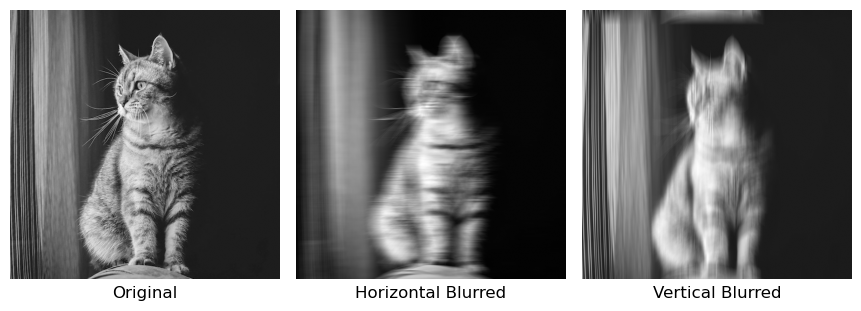

In [9]:
ex1_gray_arr = convert_img_to_norm_np_arr('./motion_deblur_img/input/Image_by_Arturo_Anez_from_Pixabay.jpg',
                                          'ex1_grayscale.jpg',
                                          grayscale=True)
length = 30
ex1_h_psf = build_horizontal_motion_psf(length, ex1_gray_arr.shape)
ex1_h_blurred = compute_blurred_img(ex1_h_psf, ex1_gray_arr)
ex1_v_psf = build_vertical_motion_psf(length, ex1_gray_arr.shape)
ex1_v_blurred = compute_blurred_img(ex1_v_psf, ex1_gray_arr)

plot_diff3(ex1_gray_arr, 'Original', ex1_h_blurred, 'Horizontal Blurred', ex1_v_blurred, 'Vertical Blurred')

### Deblur Method Comparison with Horizontal Blurred Image

(np.float64(1.3104405199848002e-18), np.float64(1.0))


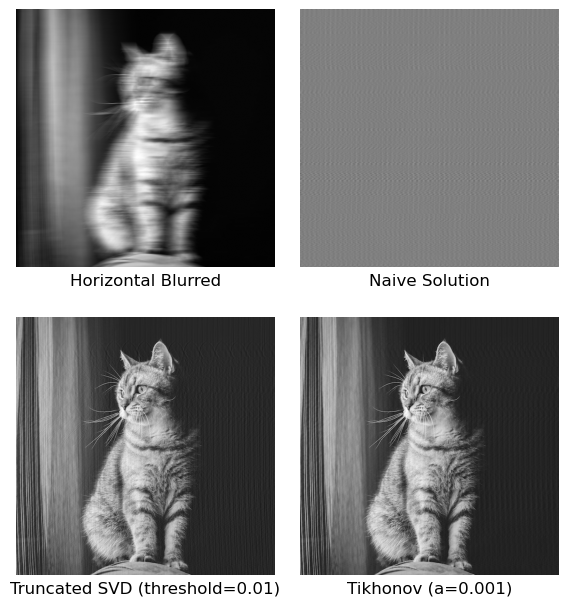

In [10]:
ex1_h_naive = compute_naive_solution(ex1_h_psf, ex1_h_blurred)
ex1_h_tsvd = compute_tsvd(ex1_h_psf, ex1_h_blurred, 0.01)

print(get_alpha_min_max(ex1_h_psf))
ex1_h_tikhonov = compute_tikhonov(ex1_h_psf, ex1_h_blurred, 0.001)

plot_diff4(ex1_h_blurred, 'Horizontal Blurred', 
           ex1_h_naive, 'Naive Solution', 
           ex1_h_tsvd, 'Truncated SVD (threshold=0.01)', 
           ex1_h_tikhonov, 'Tikhonov (a=0.001)')